<a href="https://colab.research.google.com/github/panzehui0206/AI4S-365days/blob/main/%E7%AC%AC%E4%BA%8C%E7%AB%A0%20%E7%94%9F%E5%91%BD%E7%A7%91%E5%AD%A6%E7%9A%84%E2%80%9C%E8%87%AA%E7%84%B6%E8%AF%AD%E8%A8%80%E2%80%9D%E2%80%94%E2%80%94%E5%BA%8F%E5%88%97%E5%A4%84%E7%90%86/Note4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**2026.4.16**

开始学习吧！


In [4]:
# =============================================
# Cell 1：安装依赖 + 理解 BLAST 程序选择
# =============================================
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install biopython -q

from Bio.Blast import NCBIWWW, NCBIXML
from Bio import Entrez
import matplotlib.pyplot as plt
import numpy as np
import time

Entrez.email = "panzehui0206@163.com"

print("✅ BLAST 模块已导入")
print("\n📌 常用 BLAST 程序:")
print("  blastn : 核酸 → 核酸数据库")
print("  blastp : 蛋白质 → 蛋白质数据库")
print("  blastx : 核酸(翻译) → 蛋白质数据库")
print("  tblastn : 蛋白质 → 核酸数据库(翻译)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.8 MB/s eta 0:00:00
✅ BLAST 模块已导入

📌 常用 BLAST 程序:
  blastn : 核酸 → 核酸数据库
  blastp : 蛋白质 → 蛋白质数据库
  blastx : 核酸(翻译) → 蛋白质数据库
  tblastn : 蛋白质 → 核酸数据库(翻译)


**BLAST**是什么？

一个用来在数据库中为DNA或蛋白质序列寻找“亲戚”的快速搜索引擎。

BLAST结果是什么？

一份关于搜索结果的详细档案，核心包含四个维度：

可信度 (**E-value**)：结果可信度有多高，值越小越真

质量 (**Bit-score**)：匹配度有多高，值越高越好

相似度 (**Percent** **Identity**)：百分比越高越好

完整度 (**Query** **Coverage**)：有多大部分是相似的，百分比越高越完整

In [5]:
# =============================================
# Cell 2：用 qblast 提交 BLASTP 请求
# =============================================
# 查询序列：人类胰岛素蛋白片段
query_seq = "MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKT"

print("📤 正在提交 BLASTP 请求到 NCBI...")
print("⏳ 通常需要 20-60 秒，请耐心等待...")

# 提交请求
result_handle = NCBIWWW.qblast(
    program="blastp",          # 蛋白质对蛋白质
    database="nr",             # 非冗余蛋白数据库
    sequence=query_seq,        # 查询序列
    entrez_query="Homo sapiens[Organism]",  # 可选：限定人类
    hitlist_size=10            # 只取前 10 条结果
)

# 保存结果到本地文件（便于后续重复解析）
blast_results_file = "insulin_blast.xml"
with open(blast_results_file, "w") as f:
    f.write(result_handle.read())
result_handle.close()

print(f"✅ BLAST 完成！结果已保存至: {blast_results_file}")

📤 正在提交 BLASTP 请求到 NCBI...
⏳ 通常需要 20-60 秒，请耐心等待...
✅ BLAST 完成！结果已保存至: insulin_blast.xml


In [6]:
# =============================================
# Cell 3：解析 XML，提取比对信息
# =============================================
with open(blast_results_file, "r") as f:
    blast_records = NCBIXML.parse(f)

    for record in blast_records:
        print(f"🔍 查询序列: {record.query[:30]}... (长度 {record.query_length})")
        print(f"📊 数据库: {record.database}")
        print("\n🏆 前 5 条匹配结果:\n")

        for i, alignment in enumerate(record.alignments[:5]):
            title = alignment.title
            # 获取第一条 HSP（高分片段对）
            hsp = alignment.hsps[0]

            print(f"  {i+1}. {title[:60]}...")
            print(f"     比对长度: {hsp.align_length} | 相似度: {hsp.identities}/{hsp.align_length} ({100*hsp.identities/hsp.align_length:.1f}%)")
            print(f"     E-value: {hsp.expect:.2e} | 得分: {hsp.score}")
            print(f"     比对片段:\n{hsp.query[:50]}...\n{hsp.match[:50]}...\n{hsp.sbjct[:50]}...")
            print()

🔍 查询序列: unnamed protein product... (长度 54)
📊 数据库: nr

🏆 前 5 条匹配结果:

  1. gb|ABI63346.1| insulin [Homo sapiens] >gb|KAI2558108.1| insu...
     比对长度: 54 | 相似度: 54/54 (100.0%)
     E-value: 4.75e-34 | 得分: 284.0
     比对片段:
MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFY...
MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFY...
MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFY...

  2. gb|KAI4069450.1| insulin, partial [Homo sapiens]...
     比对长度: 54 | 相似度: 54/54 (100.0%)
     E-value: 5.08e-34 | 得分: 283.0
     比对片段:
MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFY...
MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFY...
MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFY...

  3. emb|CAA08766.1| insulin, partial [Homo sapiens]...
     比对长度: 54 | 相似度: 54/54 (100.0%)
     E-value: 6.73e-34 | 得分: 280.0
     比对片段:
MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFY...
MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFY...
MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFY...

  4. ref|NP_000

In [7]:
# =============================================
# Cell 4：提取匹配序列的 Accession 并下载 FASTA
# =============================================
# 重新解析 XML，提取所有匹配序列的 Accession
accessions = []
with open(blast_results_file, "r") as f:
    records = NCBIXML.parse(f)
    for record in records:
        for alignment in record.alignments:
            # 从 title 中提取 Accession（通常在第一个空格前）
            acc = alignment.title.split()[0]
            accessions.append(acc)

print(f"📋 找到 {len(accessions)} 个匹配序列的 Accession:")
print(accessions[:5], "...")

# 批量下载 FASTA（只取前 3 个，避免请求过大）
output_fasta = "blast_hits.fasta"
with open(output_fasta, "w") as out_f:
    for acc in accessions[:3]:
        print(f"⬇️ 下载 {acc}...")
        try:
            handle = Entrez.efetch(db="protein", id=acc, rettype="fasta", retmode="text")
            seq_record = handle.read()
            out_f.write(seq_record)
            handle.close()
            time.sleep(0.5)  # 礼貌延迟，防止被封
        except Exception as e:
            print(f"   ❌ 下载失败: {e}")

print(f"\n💾 同源序列已保存至: {output_fasta}")
!head -n 6 {output_fasta}

📋 找到 10 个匹配序列的 Accession:
['gb|ABI63346.1|', 'gb|KAI4069450.1|', 'emb|CAA08766.1|', 'ref|NP_000198.1|', 'gb|WAH70529.1|'] ...
⬇️ 下载 gb|ABI63346.1|...
⬇️ 下载 gb|KAI4069450.1|...
⬇️ 下载 emb|CAA08766.1|...

💾 同源序列已保存至: blast_hits.fasta
>ABI63346.1 insulin [Homo sapiens]
MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQGSLQPLAL
EGSLQKRGIVEQCCTSICSLYQLENYCN

>KAI4069450.1 insulin, partial [Homo sapiens]
MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQAGELLQLD


这一步的目的：从 **BLAST** 结果中提取序列 **ID** ，然后去 **NCBI** 仓库把整条序列的 **FASTA** 文件都下载下来，为后续的多序列比对和进化分析铺路。



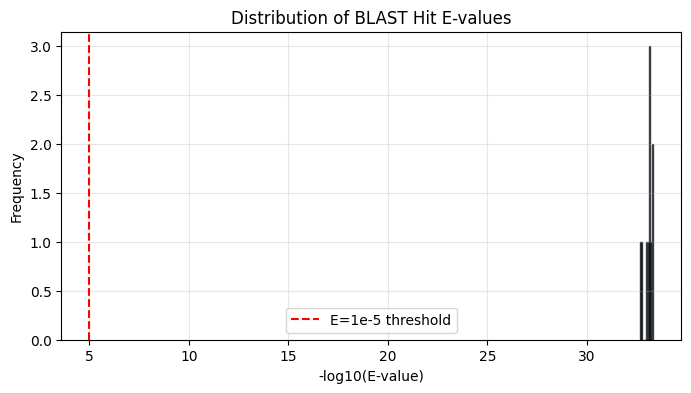

📊 总匹配数: 10
📊 E-value < 1e-5 的显著匹配: 10


In [8]:
# =============================================
# Cell 5：绘制 E-value 分布直方图
# =============================================

blast_results_file = "insulin_blast.xml"

evalues = []
with open(blast_results_file, "r") as f:
    records = NCBIXML.parse(f)
    for record in records:
        for alignment in record.alignments:
            for hsp in alignment.hsps:
                evalues.append(hsp.expect)

# 转换为 -log10(E-value) 便于显示
log_evalues = -np.log10(np.array(evalues) + 1e-200)  # 加极小值避免 log(0)

plt.figure(figsize=(8, 4))
plt.hist(log_evalues, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('-log10(E-value)')
plt.ylabel('Frequency')
plt.title('Distribution of BLAST Hit E-values')
plt.axvline(x=-np.log10(1e-5), color='red', linestyle='--', label='E=1e-5 threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"📊 总匹配数: {len(evalues)}")
print(f"📊 E-value < 1e-5 的显著匹配: {sum(np.array(evalues) < 1e-5)}")

**E-value**越小，匹配越显著。

红色虚线右侧（E < 1e-5）的匹配被认为是统计显著的同源序列。

今天学了什么呢？

✅ 理解 BLAST 的种子延伸思想及其与全局比对的区别。

✅ 使用 NCBIWWW.qblast() 提交在线 BLASTP 请求。

✅ 解析 XML 结果，提取 E-value、相似度等关键信息。

✅ 批量下载同源序列 FASTA，绘制 E-value 分布图。